In [1]:
import numpy as np
from sklearn.datasets import make_classification
import torch
import torch.nn as nn 
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

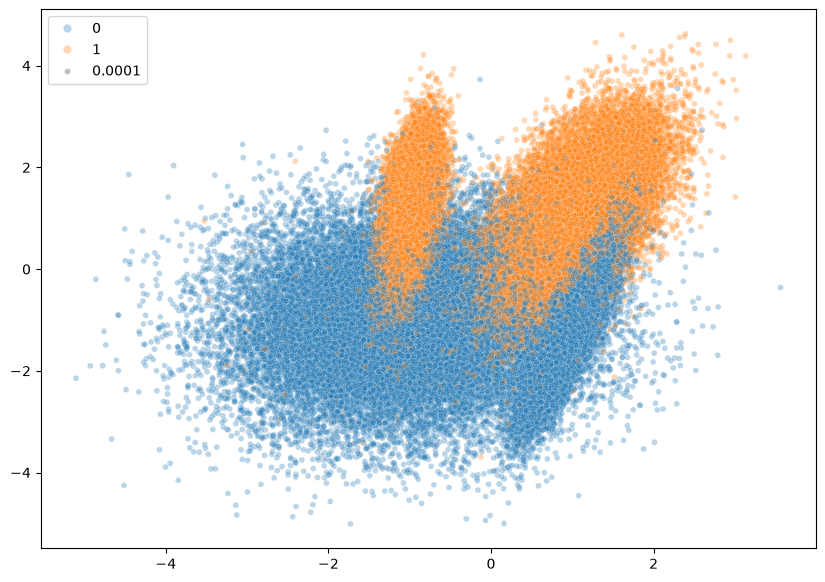

In [2]:
XTrain, yTrain = make_classification(n_samples=1_20_000, n_features=2, n_informative=2, n_classes=2, n_redundant=0, n_repeated=0, n_clusters_per_class=2, random_state=98)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=XTrain[:,0], y=XTrain[:,1], hue=yTrain, size=0.0001, alpha=0.3)
plt.show()

In [3]:
X, y = make_classification(
    n_samples=7_44_700,
    n_features=17,
    n_informative=17,
    n_clusters_per_class=7,
    random_state=42,
    n_redundant=0,
    n_repeated=0,
    n_classes=2
)

XTrain, XTemp, yTrain, yTemp = train_test_split(
    X, y,
    test_size=14_000,
    random_state=42,
    stratify=y
)

XEval, XTest, yEval, yTest = train_test_split(
    XTemp, yTemp,
    test_size=7_000,
    random_state=42,
    stratify=yTemp
)
XTrain, yTrain

(array([[-4.11667182, -0.89950848, -2.66300806, ..., -0.75948157,
          1.16800036,  1.24296324],
        [ 1.89341172, -2.05990566,  1.72959565, ..., -0.17076465,
          0.09804527,  0.29791209],
        [-4.90605909,  1.49622592,  1.00185816, ..., -7.42314854,
         -2.58117916, -2.46862475],
        ...,
        [-2.18172352, -3.33826397, -6.71275232, ...,  0.19279406,
          0.64926676, -1.49441933],
        [-1.62418017, -1.81522376, -0.11633268, ..., -3.92372021,
          0.37936233, -0.09563961],
        [ 2.57626481,  0.61884736,  3.85126583, ..., -2.81512869,
         -1.71904764,  4.26993702]], shape=(730700, 17)),
 array([0, 1, 0, ..., 0, 1, 1], shape=(730700,)))

In [4]:
torch.set_default_dtype(torch.float32)
torch.manual_seed(42)
torch.set_num_threads(10)

In [5]:
class DummyDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self, index):
        return torch.tensor(self.features[index], dtype=torch.float32), torch.tensor(self.labels[index].reshape(1), dtype=torch.float32)

In [6]:
trainDataset = DummyDataset(XTrain, yTrain)
evalDataset = DummyDataset(XEval, yEval)
testDataset = DummyDataset(XTest, yTest)

In [7]:
trainLoader = DataLoader(trainDataset, batch_size= 128, shuffle=True)
evalLoader = DataLoader(evalDataset, batch_size= len(evalDataset), shuffle=False)
testLoader = DataLoader(testDataset, batch_size=len(testDataset), shuffle=False)

In [8]:
class Model(nn.Module):
    def __init__(self, shape):
        super().__init__()
        self.neuralNet = nn.Sequential(
            nn.Linear(shape, 17),
            nn.ReLU(),
            nn.Linear(17, 17),
            nn.ReLU(),
            nn.Linear(17, 1),
            nn.Sigmoid()
        )
    
    def forward(self, X):
        return self.neuralNet(X)

In [9]:
model = Model(XTrain.shape[1])

In [10]:
lossHist = []
accHist = []

In [15]:
epochs = 100
alpha = 0.001

lossFunc = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=alpha)

for epoch in range(epochs):

    for X, y in trainLoader:

        yHat = model(X)
        loss = lossFunc(yHat, y)
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        model.eval()

        for X, y in evalLoader:
            yHat = model(X)
            loss = lossFunc(yHat, y)
            yHat = (yHat > 0.5).int()
            acc = (yHat == y).float().mean()
            lossHist.append(loss.item())
            accHist.append(acc.item())

            print(f"{epoch +1}) Evaluation accuracy: {acc.item() * 100:.2f}%")
            print(f"Evaluation loss: {loss.item()}")
        
        model.train()

1) Evaluation accuracy: 85.34%
Evaluation loss: 0.33472996950149536
2) Evaluation accuracy: 85.40%
Evaluation loss: 0.33161628246307373
3) Evaluation accuracy: 85.56%
Evaluation loss: 0.3290112316608429
4) Evaluation accuracy: 85.84%
Evaluation loss: 0.32653748989105225
5) Evaluation accuracy: 85.87%
Evaluation loss: 0.32491350173950195
6) Evaluation accuracy: 86.04%
Evaluation loss: 0.32210037112236023
7) Evaluation accuracy: 86.01%
Evaluation loss: 0.32027581334114075
8) Evaluation accuracy: 85.91%
Evaluation loss: 0.31816092133522034
9) Evaluation accuracy: 86.07%
Evaluation loss: 0.31642401218414307
10) Evaluation accuracy: 86.20%
Evaluation loss: 0.3145127594470978
11) Evaluation accuracy: 86.34%
Evaluation loss: 0.31309881806373596
12) Evaluation accuracy: 86.41%
Evaluation loss: 0.31105783581733704
13) Evaluation accuracy: 86.50%
Evaluation loss: 0.31021806597709656
14) Evaluation accuracy: 86.40%
Evaluation loss: 0.30843913555145264
15) Evaluation accuracy: 86.71%
Evaluation lo

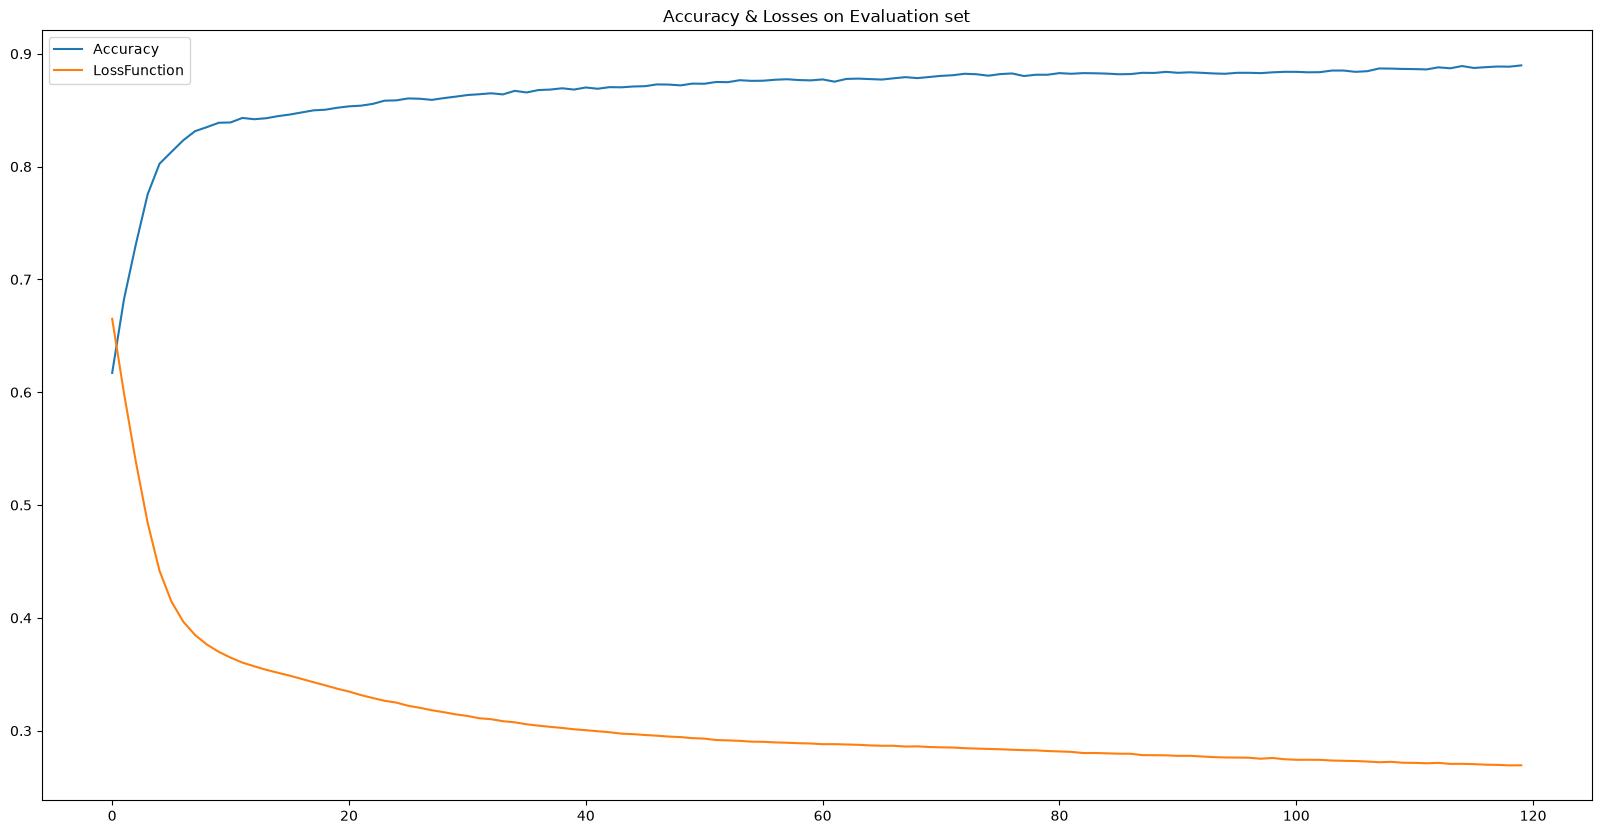

In [16]:
plt.figure(figsize=(20, 10))
plt.title("Accuracy & Losses on Evaluation set")
plt.plot(accHist, label = "Accuracy")
plt.plot(lossHist, label = "LossFunction")
plt.legend(loc="best")
plt.show()